To Do: Implementation – SVM(for Classification)

Linear Kernel Accuracy: 1.0


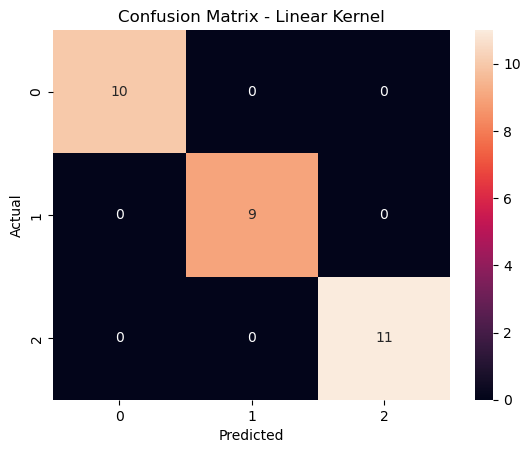

RBF Kernel Accuracy: 1.0


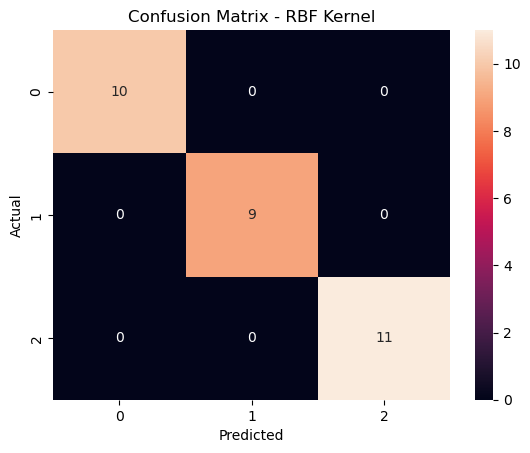

In [1]:
''' Build a SVM classifier to classify IRIS flower dataset using the kernels RBF and linear.
Use 80% of data for training and 20% for testing.
Display accuracy score and confusion matrix of the trained model on test data.
'''

# SVM Classification for IRIS Dataset

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix

# Load dataset
data = pd.read_excel("iris (1).xlsx")

# Features and target
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

# Train-Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# Linear Kernel SVM
# -----------------------------
linear_svm = SVC(kernel='linear')
linear_svm.fit(X_train, y_train)

y_pred_linear = linear_svm.predict(X_test)

print("Linear Kernel Accuracy:", accuracy_score(y_test, y_pred_linear))

cm_linear = confusion_matrix(y_test, y_pred_linear)

plt.figure()
sns.heatmap(cm_linear, annot=True, fmt='d')
plt.title("Confusion Matrix - Linear Kernel")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# -----------------------------
# RBF Kernel SVM
# -----------------------------
rbf_svm = SVC(kernel='rbf')
rbf_svm.fit(X_train, y_train)

y_pred_rbf = rbf_svm.predict(X_test)

print("RBF Kernel Accuracy:", accuracy_score(y_test, y_pred_rbf))

cm_rbf = confusion_matrix(y_test, y_pred_rbf)

plt.figure()
sns.heatmap(cm_rbf, annot=True, fmt='d')
plt.title("Confusion Matrix - RBF Kernel")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Accuracy: 0.35825


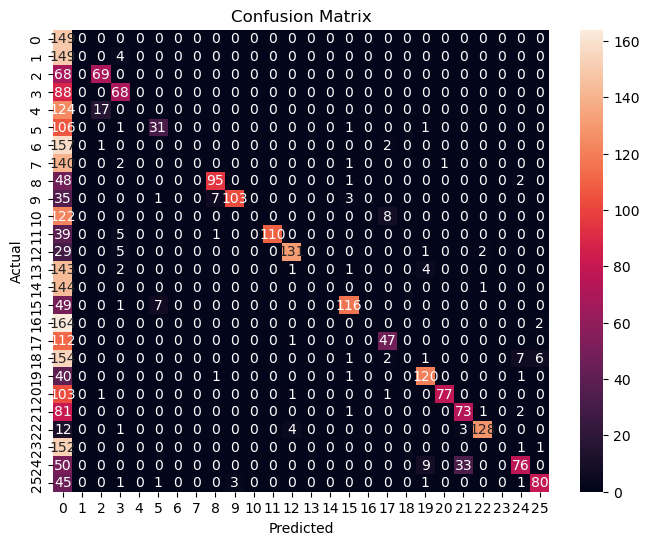

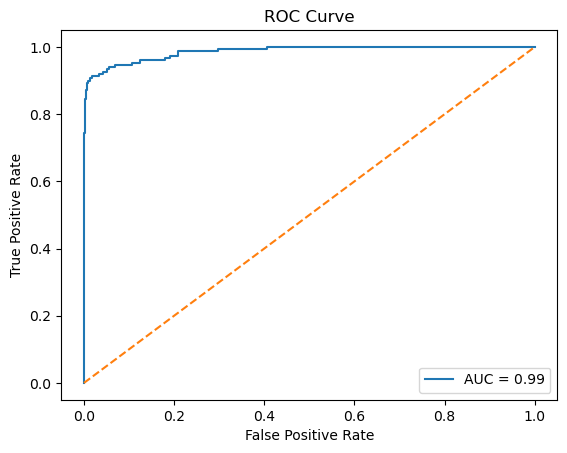

AUC Score: 0.9859375844154485


In [2]:
''' Build a SVM classifier to classify Letter-recognition data set
Use 80% of data for training and 20% for testing.
Display accuracy score and confusion matrix of the trained model on test data. Plot the ROC curve and display AUC score.
'''

# SVM Classification for Letter Recognition Dataset

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.multiclass import OneVsRestClassifier

# Load dataset
data = pd.read_excel("letter-recognition.xlsx")

# Features and target
X = data.iloc[:, 1:]
y = data.iloc[:, 0]

# Binarize labels
classes = sorted(y.unique())
y_bin = label_binarize(y, classes=classes)

# Train-Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_bin, test_size=0.2, random_state=42
)

# Train SVM
model = OneVsRestClassifier(SVC(kernel='linear', probability=True))
model.fit(X_train, y_train)

# Predictions
y_score = model.decision_function(X_test)
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Confusion Matrix
cm = confusion_matrix(
    y_test.argmax(axis=1),
    y_pred.argmax(axis=1)
)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
# ROC Curve
fpr, tpr, _ = roc_curve(y_test[:,0], y_score[:,0])
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label="AUC = %0.2f" % roc_auc)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("AUC Score:", roc_auc)